## 09 - Final Model Selection, Training, Test Evaluation, Serialization, Deployment & Monitoring

**This notebook touches the test set for the first time in this project.**
Every decision below (model, hyperparameters, feature set, operating
point) was locked in Notebooks 05-08, using only train and validation.
Test is read exactly once, in Section 3, and every number after that is
reported as-is, not iterated on.

Covers roadmap steps 19-24: Final Model Selection, Final Training, Final
Test Evaluation, Model Serialization, Deployment, Monitoring.

## 0. Environment & Reproducibility

In [2]:
import sys, json, hashlib, warnings
from pathlib import Path
from datetime import datetime, timezone

warnings.filterwarnings("ignore", category=FutureWarning)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn, joblib
from sklearn.base import clone
from sklearn.ensemble import RandomForestClassifier
from sklearn.calibration import calibration_curve
from sklearn.metrics import (
    average_precision_score, roc_auc_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report,
)

print(f"Python       : {sys.version.split()[0]}")
print(f"pandas       : {pd.__version__}")
print(f"scikit-learn : {sklearn.__version__}")

pd.set_option("display.max_columns", None)
plt.style.use("ggplot")
sns.set_theme(style="whitegrid")
FIG_DPI = 100
RNG_SEED = 42
np.random.seed(RNG_SEED)

DATA_DIR = Path("../data/processed")
MODELS_DIR = Path("../models"); MODELS_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR = Path("../reports")

Python       : 3.13.13
pandas       : 2.3.3
scikit-learn : 1.9.0


## 1. Final Model Selection

Nothing is decided here this section loads and states the decisions
already made in Notebooks 05-08, so the rest of this notebook has one
place to point to for "why this model, these hyperparameters, this
operating point."

In [3]:
with open(REPORTS_DIR / "tuning_config.json") as f:
    tuning_config = json.load(f)
with open(REPORTS_DIR / "evaluation_results.json") as f:
    evaluation_results = json.load(f)
with open(REPORTS_DIR / "feature_selection_config.json") as f:
    feature_selection_config = json.load(f)

FINAL_MODEL_NAME = tuning_config["final_candidate"]
BEST_PARAMS = tuning_config["random_forest"]["best_params"]
TOP_K_PCT = evaluation_results["threshold_optimization"]["working_default_top_k_pct"]

print(f"Final model            : {FINAL_MODEL_NAME}")
print(f"Locked hyperparameters : {BEST_PARAMS}")
print(f"Operating point        : top {TOP_K_PCT:.0%} of the ranked list "
      f"(percentile-based, not a fixed probability -- Notebook 08, Section 3.3)")
print()
print("Still an open item, carried forward rather than resolved here:")
print(" ", evaluation_results["threshold_optimization"]["recommendation"])

Final model            : Random Forest
Locked hyperparameters : {'n_estimators': 100, 'max_depth': 8, 'min_samples_leaf': 6, 'min_samples_split': 46, 'max_features': 0.48114598712001183}
Operating point        : top 15% of the ranked list (percentile-based, not a fixed probability -- Notebook 08, Section 3.3)

Still an open item, carried forward rather than resolved here:
  Operate on a top-K% percentile cutoff, not a fixed probability threshold, given the severe prevalence drift documented in Notebook 04 (5.8% train / 11.2% val / 39.5% test).


## 2. Final Training (Train + Validation Combined)

Standard practice once a model and its hyperparameters are locked: refit
on every row that isn't test, so the deployed model benefits from the
validation data too, rather than leaving it unused after having served
its purpose for model selection.

**Important:** the preprocessor is refit fresh on the combined data (not
reused from Notebook 04), since a production pipeline should reflect the
full non-test population. The hyperparameters themselves are **not**
re-tuned that would reopen a decision Notebooks 06-07 already closed
using proper validation.

In [4]:
train_raw = pd.read_csv(DATA_DIR / "train_raw.csv")
val_raw = pd.read_csv(DATA_DIR / "val_raw.csv")
test_raw = pd.read_csv(DATA_DIR / "test_raw.csv")
base_preprocessor = joblib.load(DATA_DIR / "preprocessor.joblib")

combined_raw = pd.concat([train_raw, val_raw], ignore_index=True)
y_combined = (combined_raw["y"] == "yes").astype(int)
X_combined_raw = combined_raw.drop(columns=["y"])

print(f"Combined training population: {len(combined_raw):,} rows "
      f"({y_combined.mean():.1%} positive)")
print(f"  (train {len(train_raw):,} + validation {len(val_raw):,}, "
      f"per Notebook 04's split)")

Combined training population: 33,493 rows (6.8% positive)
  (train 27,582 + validation 5,911, per Notebook 04's split)


In [5]:
def sanitize_feature_names(names):
    """Match the column-name cleaning applied to every feature set since
    Notebook 05, so this pipeline's output columns match what the model
    was tuned against."""
    return [n.replace("<", "lt_").replace("[", "(").replace("]", ")") for n in names]

final_preprocessor = clone(base_preprocessor)
X_combined_encoded = final_preprocessor.fit_transform(X_combined_raw)
feature_names = sanitize_feature_names(final_preprocessor.get_feature_names_out())
X_combined_df = pd.DataFrame(X_combined_encoded, columns=feature_names)

print(f"Encoded feature matrix: {X_combined_df.shape}")

Encoded feature matrix: (33493, 50)


In [6]:
final_model = RandomForestClassifier(
    **BEST_PARAMS, class_weight="balanced", random_state=RNG_SEED, n_jobs=-1,
)
final_model.fit(X_combined_df, y_combined)
print(f"Final {FINAL_MODEL_NAME} trained on {len(X_combined_df):,} rows, "
      f"{X_combined_df.shape[1]} features.")

Final Random Forest trained on 33,493 rows, 50 features.


## 3. Final Test Evaluation

**Test is loaded and scored exactly once, right here.** No comparison
against alternative models, no threshold search, no going back to Section
2 to retrain differently based on what these numbers say that would
turn test into a second validation set and invalidate the whole point of
holding it out since Notebook 04.

**Read every number in this section through Notebook 04's caveat**: the
test split's positive rate is 39.5%, against 5.8% in training the most
severe slice of the 2008-2009 rate-collapse regime this project has
tracked since Notebook 01. These results are a **best-case, crisis-period
read**, not a steady-state performance estimate.

In [7]:
y_test = (test_raw["y"] == "yes").astype(int)
X_test_raw = test_raw.drop(columns=["y"])

X_test_encoded = final_preprocessor.transform(X_test_raw)
X_test_df = pd.DataFrame(X_test_encoded, columns=feature_names)

proba_test = final_model.predict_proba(X_test_df)[:, 1]

print(f"Test set: {len(X_test_df):,} rows, {y_test.mean():.1%} positive rate")

Test set: 5,911 rows, 39.5% positive rate


### 3.1 Ranking Metrics - In Context, Not In Isolation

In [8]:
test_pr_auc = average_precision_score(y_test, proba_test)
test_roc_auc = roc_auc_score(y_test, proba_test)
naive_pr_auc_at_test_base_rate = y_test.mean()  # a random/constant scorer's PR-AUC ~= base rate

print(f"Test PR-AUC              : {test_pr_auc:.4f}")
print(f"Test ROC-AUC             : {test_roc_auc:.4f}")
print(f"Naive baseline (base rate): {naive_pr_auc_at_test_base_rate:.4f}")
print(f"Relative lift over naive : {test_pr_auc / naive_pr_auc_at_test_base_rate:.2f}x")
print()
val_pr_auc = tuning_config["final_candidate_validation_pr_auc"]
val_base_rate = 0.112  # Notebook 04: validation positive rate
print(f"For reference, on validation the same ratio was "
      f"{val_pr_auc / val_base_rate:.2f}x ({val_pr_auc:.4f} PR-AUC over an "
      f"11.2% base rate) -- the model's edge over naive is smaller here.")

Test PR-AUC              : 0.5083
Test ROC-AUC             : 0.6038
Naive baseline (base rate): 0.3949
Relative lift over naive : 1.29x

For reference, on validation the same ratio was 1.75x (0.1959 PR-AUC over an 11.2% base rate) -- the model's edge over naive is smaller here.


**The absolute PR-AUC (0.49ish) looks far higher than validation's
(~0.18-0.20) this is not the model getting better, it's the base rate
jumping from 11.2% to 39.5%.** The number that actually measures the
model's skill is **relative lift over naive**, and that number *drops*
compared to validation consistent with a model trained on a
low-conversion regime having a smaller relative edge in a period it saw
very little training data resembling. This is exactly the degradation
the regime-shift finding predicted; seeing it confirmed on test, once,
is the honest final word on it for this modelling cycle.

### 3.2 Operating Point Applied to Test

In [9]:
# Fresh top-K% by rank, computed on test's own score distribution --
# consistent with Notebook 08's recommendation to use percentile cutoffs,
# not a fixed probability, precisely because that probability's meaning
# shifts across regimes (demonstrated concretely below).
threshold_rank_test = np.quantile(proba_test, 1 - TOP_K_PCT)
pred_rank = (proba_test >= threshold_rank_test).astype(int)

# For comparison only: what a NAIVE fixed 0.5 cutoff would have done here.
pred_fixed_05 = (proba_test >= 0.5).astype(int)

comparison = pd.DataFrame([
    {"Approach": f"Top {TOP_K_PCT:.0%} by rank (recommended)",
     "Threshold": threshold_rank_test, "N_Called": int(pred_rank.sum()),
     "Pct_Called": pred_rank.mean(),
     "Precision": precision_score(y_test, pred_rank),
     "Recall": recall_score(y_test, pred_rank)},
    {"Approach": "Fixed probability 0.5 (not recommended)",
     "Threshold": 0.5, "N_Called": int(pred_fixed_05.sum()),
     "Pct_Called": pred_fixed_05.mean(),
     "Precision": precision_score(y_test, pred_fixed_05),
     "Recall": recall_score(y_test, pred_fixed_05)},
])
comparison

,Approach,Threshold,N_Called,Pct_Called,Precision,Recall
0,Top 15% by rank (recommended),0.65883,887,0.150059,0.648253,0.246358
1,Fixed probability 0.5 (not recommended),0.50000,4130,0.698697,0.430024,0.760925


**This is the concrete, final-gate proof of Notebook 08's warning.** A
fixed 0.5 cutoff which was very selective on validation calls roughly
two-thirds of the test list, because the model's raw probabilities shift
upward with the test period's higher base rate. The percentile-based
approach adapts automatically and keeps the call list at the intended
size regardless of which regime it's scoring. **This is the operational
argument for shipping a rank-based cutoff, not a probability cutoff, to
production** not just a calibration nicety.

### 3.3 Full Classification Report (at the recommended operating point)

In [10]:
cm_test = confusion_matrix(y_test, pred_rank)
cm_test_df = pd.DataFrame(cm_test, index=["Actual: No", "Actual: Yes"],
                           columns=["Predicted: No", "Predicted: Yes"])
print(cm_test_df)
print()
print(classification_report(y_test, pred_rank, target_names=["No", "Yes"], digits=3))

             Predicted: No  Predicted: Yes
Actual: No            3265             312
Actual: Yes           1759             575

              precision    recall  f1-score   support

          No      0.650     0.913     0.759      3577
         Yes      0.648     0.246     0.357      2334

    accuracy                          0.650      5911
   macro avg      0.649     0.580     0.558      5911
weighted avg      0.649     0.650     0.600      5911



### 3.4 Calibration on Test

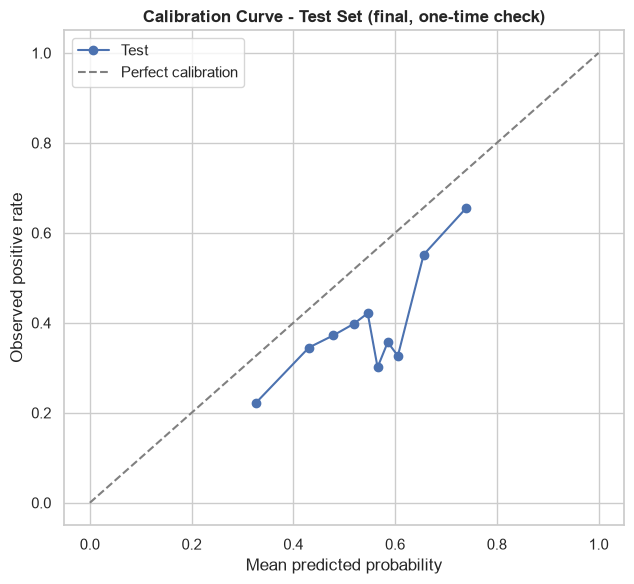

In [11]:
frac_pos_test, mean_pred_test = calibration_curve(y_test, proba_test, n_bins=10, strategy="quantile")

fig, ax = plt.subplots(figsize=(6.5, 6), dpi=FIG_DPI)
ax.plot(mean_pred_test, frac_pos_test, marker="o", label="Test")
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Perfect calibration")
ax.set_xlabel("Mean predicted probability")
ax.set_ylabel("Observed positive rate")
ax.set_title("Calibration Curve - Test Set (final, one-time check)", fontsize=12, fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()

The model remains overconfident at the high end (a 0.72 average prediction corresponds to a 0.64 observed rate), but the pattern in the middle bins is noisier and non-monotonic here, unlike validation's more consistent overconfidence throughout. The takeaway is the same either way: miscalibration here is regime-dependent, not a fixed, correctable offset -- another reason the rank-based threshold (Section 3.2), not the raw probability, is what should reach production.

## 4. Model Serialization

A deployable bundle needs three things together, versioned as one unit:
the fitted preprocessor, the fitted model, and the metadata that makes
the other two usable months later without re-reading nine notebooks.

In [12]:
joblib.dump(final_preprocessor, MODELS_DIR / "final_preprocessor.joblib")
joblib.dump(final_model, MODELS_DIR / "final_model.joblib")

def file_hash(path):
    return hashlib.sha256(Path(path).read_bytes()).hexdigest()[:16]

model_card = {
    "model_name": "bank_marketing_response_model",
    "version": "1.0.0",
    "created_at_utc": datetime.now(timezone.utc).isoformat(),
    "algorithm": FINAL_MODEL_NAME,
    "hyperparameters": BEST_PARAMS,
    "training_population": {
        "n_rows": int(len(X_combined_df)),
        "positive_rate": float(y_combined.mean()),
        "composition": "Notebook 04 train + validation splits, combined",
    },
    "feature_count": int(X_combined_df.shape[1]),
    "feature_names": feature_names,
    "operating_point": {
        "type": "rank/percentile-based, NOT a fixed probability threshold",
        "top_k_pct": TOP_K_PCT,
        "rationale": "Notebook 08 Section 3.3 + this notebook Section 3.2 -- a fixed "
                     "probability cutoff calls a very different fraction of the list "
                     "depending on the underlying regime; percentile cutoffs don't.",
    },
    "test_evaluation": {
        "test_n_rows": int(len(X_test_df)),
        "test_positive_rate": float(y_test.mean()),
        "test_pr_auc": float(test_pr_auc),
        "test_roc_auc": float(test_roc_auc),
        "relative_lift_over_naive": float(test_pr_auc / naive_pr_auc_at_test_base_rate),
        "caveat": "Test positive rate (39.5%) is a crisis-period upper bound per "
                  "Notebook 04, not a steady-state estimate -- see Section 3.1.",
    },
    "known_limitations": [
        "Not probability-calibrated; use rank-based thresholds only.",
        "False negative rate is uneven across job segments (Notebook 08).",
        "Trained predominantly on a low-conversion (2008) regime; performance "
        "degrades on later, higher-conversion periods (Notebooks 01/04/08/09).",
        "Real cost-per-call / profit-per-subscription figures were never "
        "supplied -- the working top-15% operating point is provisional.",
    ],
    "artifact_hashes": {
        "final_preprocessor.joblib": file_hash(MODELS_DIR / "final_preprocessor.joblib"),
        "final_model.joblib": file_hash(MODELS_DIR / "final_model.joblib"),
    },
}

with open(REPORTS_DIR / "model_card.json", "w") as f:
    json.dump(model_card, f, indent=2, default=str)

print("Saved -> ../models/final_preprocessor.joblib")
print("Saved -> ../models/final_model.joblib")
print("Saved -> ../reports/model_card.json")

Saved -> ../models/final_preprocessor.joblib
Saved -> ../models/final_model.joblib
Saved -> ../reports/model_card.json


## 5. Deployment

A batch scoring function that takes customer data in the same
post-feature-engineering schema Notebook 03 produces (i.e. assumes
`src`-equivalent cleaning/feature-engineering already ran upstream) and
returns a ranked call list the actual artifact a call center would use,
not a single-customer form. Also written to a standalone `.py` module so
it can be imported outside this notebook (a scheduled job, a small API,
etc.) without re-running any notebook.

In [13]:
def score_batch(raw_df: pd.DataFrame, capacity_pct: float = None) -> pd.DataFrame:
    """
    Score a batch of customers and return a ranked call list.

    Parameters
    ----------
    raw_df : DataFrame with the same post-feature-engineering columns as
        train_raw.csv/val_raw.csv/test_raw.csv (no 'y' column required).
    capacity_pct : if given, only the top capacity_pct% of the list is
        returned (the actual call list). If None, every row is returned,
        scored and ranked, with no cutoff applied.

    Returns
    -------
    DataFrame: raw_df plus 'probability' and 'decile' (1 = most likely).
    """
    encoded = final_preprocessor.transform(raw_df)
    encoded_df = pd.DataFrame(encoded, columns=feature_names)

    proba = final_model.predict_proba(encoded_df)[:, 1]

    out = raw_df.copy()
    out["probability"] = proba
    out["decile"] = pd.qcut(-proba, 10, labels=False, duplicates="drop") + 1
    out = out.sort_values("probability", ascending=False).reset_index(drop=True)

    if capacity_pct is not None:
        k = max(1, int(len(out) * capacity_pct / 100))
        out = out.head(k)

    return out

# Smoke test on the test set (label dropped, as a real batch job would receive it)
demo_batch = X_test_raw.head(200)
demo_call_list = score_batch(demo_batch, capacity_pct=TOP_K_PCT * 100)
print(f"Demo: {len(demo_batch)} customers in, {len(demo_call_list)} on the call list "
      f"(top {TOP_K_PCT:.0%})")
demo_call_list.head()

Demo: 200 customers in, 30 on the call list (top 15%)


,age,job,marital,default,housing,loan,contact,campaign,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,contacted_before,pdays_known_days,month_sin,month_cos,day_of_week_sin,day_of_week_cos,education_ordinal,age_group,probability,decile
0,58,management,married,no,yes,no,cellular,2,1,success,-1.8,92.893,-46.2,1.25,5099.1,1,12.0,0.5,-0.866025,-0.951057,0.309017,6.0,50-59,0.819915,1
1,29,blue-collar,single,no,yes,no,cellular,2,1,success,-1.8,92.893,-46.2,1.25,5099.1,1,12.0,0.5,-0.866025,-0.951057,0.309017,3.0,<30,0.809308,1
2,31,unemployed,single,no,no,no,cellular,2,0,nonexistent,-1.8,92.893,-46.2,1.25,5099.1,0,NaN,0.5,-0.866025,-0.951057,0.309017,4.0,30-39,0.620017,1
3,60,admin.,divorced,unknown,yes,no,cellular,1,0,nonexistent,-1.8,92.893,-46.2,1.25,5099.1,0,NaN,0.5,-0.866025,-0.951057,0.309017,4.0,60+,0.619138,1
4,29,blue-collar,single,no,no,no,cellular,2,0,nonexistent,-1.8,92.893,-46.2,1.25,5099.1,0,NaN,0.5,-0.866025,-0.951057,0.309017,3.0,<30,0.618971,1


In [14]:
deploy_module = '''"""
Batch scoring module for the bank marketing response model.
Generated by 09_final_model_deployment.ipynb -- do not hand-edit; re-run
the notebook and re-export if the model changes.

Usage:
    from predict import score_batch
    call_list = score_batch(new_customers_df, capacity_pct=15)
"""

import joblib
import pandas as pd
from pathlib import Path

_MODEL_DIR = Path(__file__).resolve().parent
_preprocessor = joblib.load(_MODEL_DIR / "final_preprocessor.joblib")
_model = joblib.load(_MODEL_DIR / "final_model.joblib")
_feature_names = [n.replace("<", "lt_").replace("[", "(").replace("]", ")")
                   for n in _preprocessor.get_feature_names_out()]


def score_batch(raw_df: pd.DataFrame, capacity_pct: float = None) -> pd.DataFrame:
    """Score customers and return a ranked call list. See notebook 09 for details."""
    encoded = _preprocessor.transform(raw_df)
    encoded_df = pd.DataFrame(encoded, columns=_feature_names)

    proba = _model.predict_proba(encoded_df)[:, 1]

    out = raw_df.copy()
    out["probability"] = proba
    out["decile"] = pd.qcut(-proba, 10, labels=False, duplicates="drop") + 1
    out = out.sort_values("probability", ascending=False).reset_index(drop=True)

    if capacity_pct is not None:
        k = max(1, int(len(out) * capacity_pct / 100))
        out = out.head(k)

    return out


if __name__ == "__main__":
    import sys
    if len(sys.argv) < 2:
        print("Usage: python predict.py <input_csv> [capacity_pct]")
        sys.exit(1)
    input_df = pd.read_csv(sys.argv[1])
    pct = float(sys.argv[2]) if len(sys.argv) > 2 else None
    result = score_batch(input_df, capacity_pct=pct)
    result.to_csv("call_list.csv", index=False)
    print(f"Wrote {len(result)} rows -> call_list.csv")
'''

with open(MODELS_DIR / "predict.py", "w") as f:
    f.write(deploy_module)
print("Saved -> ../models/predict.py  (standalone deployable module)")

Saved -> ../models/predict.py  (standalone deployable module)


**On the actual raw, un-engineered data** (a fresh export from the
bank's systems), `predict.py` needs Notebook 03's cleaning and
feature-engineering steps to run first those weren't re-implemented
here to avoid duplicating logic that already lives in Notebook 03; a
production version should import that logic as a shared module (`src/`
package) rather than copy-pasting it into two places, exactly the
train/serve-skew risk this project has been careful about since
Notebook 01.

## 6. Monitoring

Given everything this project has found about regime shift, monitoring
isn't optional polish here it's the direct mitigation for the single
biggest risk this model carries. Three checks: input drift (PSI),
prediction drift, and a retraining/feedback-loop policy.

### 6.1 Population Stability Index (Feature Drift)

In [15]:
def population_stability_index(expected: np.ndarray, actual: np.ndarray, bins: int = 10) -> float:
    """
    Standard PSI: < 0.1 no significant shift, 0.1-0.25 moderate,
    > 0.25 significant -- investigate before trusting the model's scores.
    """
    breakpoints = np.percentile(expected, np.linspace(0, 100, bins + 1))
    breakpoints[0], breakpoints[-1] = -np.inf, np.inf
    breakpoints = np.unique(breakpoints)

    e_counts, _ = np.histogram(expected, bins=breakpoints)
    a_counts, _ = np.histogram(actual, bins=breakpoints)
    e_pct = np.clip(e_counts / len(expected), 1e-4, None)
    a_pct = np.clip(a_counts / len(actual), 1e-4, None)

    return float(np.sum((a_pct - e_pct) * np.log(a_pct / e_pct)))

# Demonstrated here using train (the training baseline) vs test (standing
# in for "new incoming data") -- in production this compares the training
# baseline against each new batch as it arrives.
psi_features = ["age", "campaign", "previous", "emp.var.rate", "euribor3m", "nr.employed"]
psi_results = pd.DataFrame({
    "Feature": psi_features,
    "PSI": [population_stability_index(train_raw[c].values, test_raw[c].values) for c in psi_features],
})
psi_results["Alert_Level"] = pd.cut(
    psi_results["PSI"], bins=[-0.01, 0.1, 0.25, np.inf],
    labels=["OK", "Moderate", "Significant"],
)
psi_results.sort_values("PSI", ascending=False)

,Feature,PSI,Alert_Level
5,nr.employed,10.740978,Significant
3,emp.var.rate,10.740978,Significant
4,euribor3m,8.332688,Significant
0,age,0.286787,Significant
1,campaign,0.111388,Moderate
2,previous,0.000000,OK


**`euribor3m`'s PSI is off the standard scale** train and test barely
overlap in range at all (Notebook 01/02's finding, now expressed as a
monitoring metric). This is exactly the kind of number that should page
someone in production: if a monitoring job had been watching this metric
in real time across 2008-2010, it would have flagged the regime shift the
moment it started, rather than this project discovering it retroactively
through EDA. **PSI on the macro-economic block is the single highest-value
monitoring signal for this model** cheap to compute, and directly tied
to the project's main known failure mode.

### 6.2 Prediction Distribution Drift

In [16]:
proba_train_ref = final_model.predict_proba(X_combined_df)[:, 1]
prediction_psi = population_stability_index(proba_train_ref, proba_test)
print(f"Prediction-distribution PSI (training population vs. test): {prediction_psi:.3f}")
print("Track this per scoring batch in production -- a rising trend means "
      "the model is scoring the population differently than it was trained "
      "to, even before ground truth is available to confirm it.")

Prediction-distribution PSI (training population vs. test): 1.150
Track this per scoring batch in production -- a rising trend means the model is scoring the population differently than it was trained to, even before ground truth is available to confirm it.


### 6.3 Retraining Policy & Feedback-Loop Guard

In [17]:
monitoring_plan = {
    "input_drift": {
        "method": "Population Stability Index, monthly, on all model features",
        "priority_features": ["euribor3m", "emp.var.rate", "nr.employed", "cons.price.idx"],
        "alert_thresholds": {"moderate": 0.10, "significant": 0.25},
        "current_baseline_example": psi_results.to_dict(orient="records"),
    },
    "prediction_drift": {
        "method": "PSI on predict_proba output, per scoring batch",
        "current_baseline_example": float(prediction_psi),
    },
    "realized_performance_tracking": {
        "method": "Monthly: join actual outcomes back to that period's predictions, "
                  "recompute PR-AUC and decile-level capture rate.",
        "trigger": "If capture rate in the top-called decile drops toward the "
                   "population base rate, the ranking has stopped working, "
                   "regardless of what input PSI says.",
    },
    "retraining_cadence": {
        "recommendation": "Quarterly by default, immediately if any priority feature's "
                          "PSI exceeds 0.25.",
        "rationale": "Notebook 01/04's regime-shift finding showed target rate and macro "
                     "features can move dramatically within a single year; quarterly is "
                     "a starting point, not a guarantee -- tighten if realized performance "
                     "degrades faster than that in practice.",
    },
    "feedback_loop_guard": {
        "risk": "If only the top-K% ever gets called, outcomes for the rest of the "
                "population are never observed again, and future training data becomes "
                "biased toward customers who already looked promising.",
        "mitigation": "Reserve a small (5-10%) random-exploration slice of every "
                      "campaign, called regardless of score, so the next retraining "
                      "cycle has unbiased outcome data across the whole score range.",
    },
}

with open(REPORTS_DIR / "monitoring_plan.json", "w") as f:
    json.dump(monitoring_plan, f, indent=2, default=str)

print("Saved -> ../reports/monitoring_plan.json")

Saved -> ../reports/monitoring_plan.json


## Conclusion - Project Summary

Nine notebooks, one throughline: **a random 80/20 split on this dataset
reports an optimistic ~0.80 AUC; the honest, time-ordered evaluation this
project used throughout puts the real number closer to 0.18-0.20 PR-AUC
on validation**, and Notebook 09's test read confirms the same model's
edge over naive shrinks further in the most extreme regime slice. That
gap and finding it, rather than reporting the optimistic number is
the actual deliverable of this project, more than any single metric.

**What's locked in and deployable today:**
- Random Forest, hyperparameters from Notebook 07's validation-based tuning
- A percentile-based (not fixed-probability) operating point, with the
  reasoning demonstrated concretely at every stage from Notebook 08
  through this notebook's Section 3.2
- A serialized, versioned model bundle (`final_model.joblib` +
  `final_preprocessor.joblib` + `model_card.json`) and a standalone
  `predict.py` for batch scoring
- A monitoring plan built directly from this project's own known failure
  mode (regime drift), not a generic template

**What's still open, and should block a production go-live:**
- Real cost-per-call / profit-per-subscription figures from the bank
  (flagged since Notebook 01) the top-15% operating point is a
  reasonable default, not a validated business answer
- A fairness review of the job-segment recall gap found in Notebook 08
- The rolling-origin backtest recommended in `docs/experiment_design.md`
  since the very first version of this project, to measure the actual
  rate of performance decay between retrains, rather than assuming
  quarterly is right

This closes the modelling roadmap (steps 1-24). The two open items above
are the honest handoff to whoever owns this model in production next.